<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3044 entries, 0 to 3043
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Sr No              3044 non-null   int64 
 1   Date dd/mm/yyyy    3044 non-null   object
 2   Startup Name       3044 non-null   object
 3   Industry Vertical  2873 non-null   object
 4   SubVertical        2108 non-null   object
 5   City  Location     2864 non-null   object
 6   Investors Name     3020 non-null   object
 7   InvestmentnType    3040 non-null   object
 8   Amount in USD      2084 non-null   object
 9   Remarks            419 non-null    object
dtypes: int64(1), object(9)
memory usage: 237.9+ KB


/tmp/ipykernel_2481/133573219.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['industry'].fillna(df['industry'].mode()[0], inplace=True)
/tmp/ipykernel_2481/133573219.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace

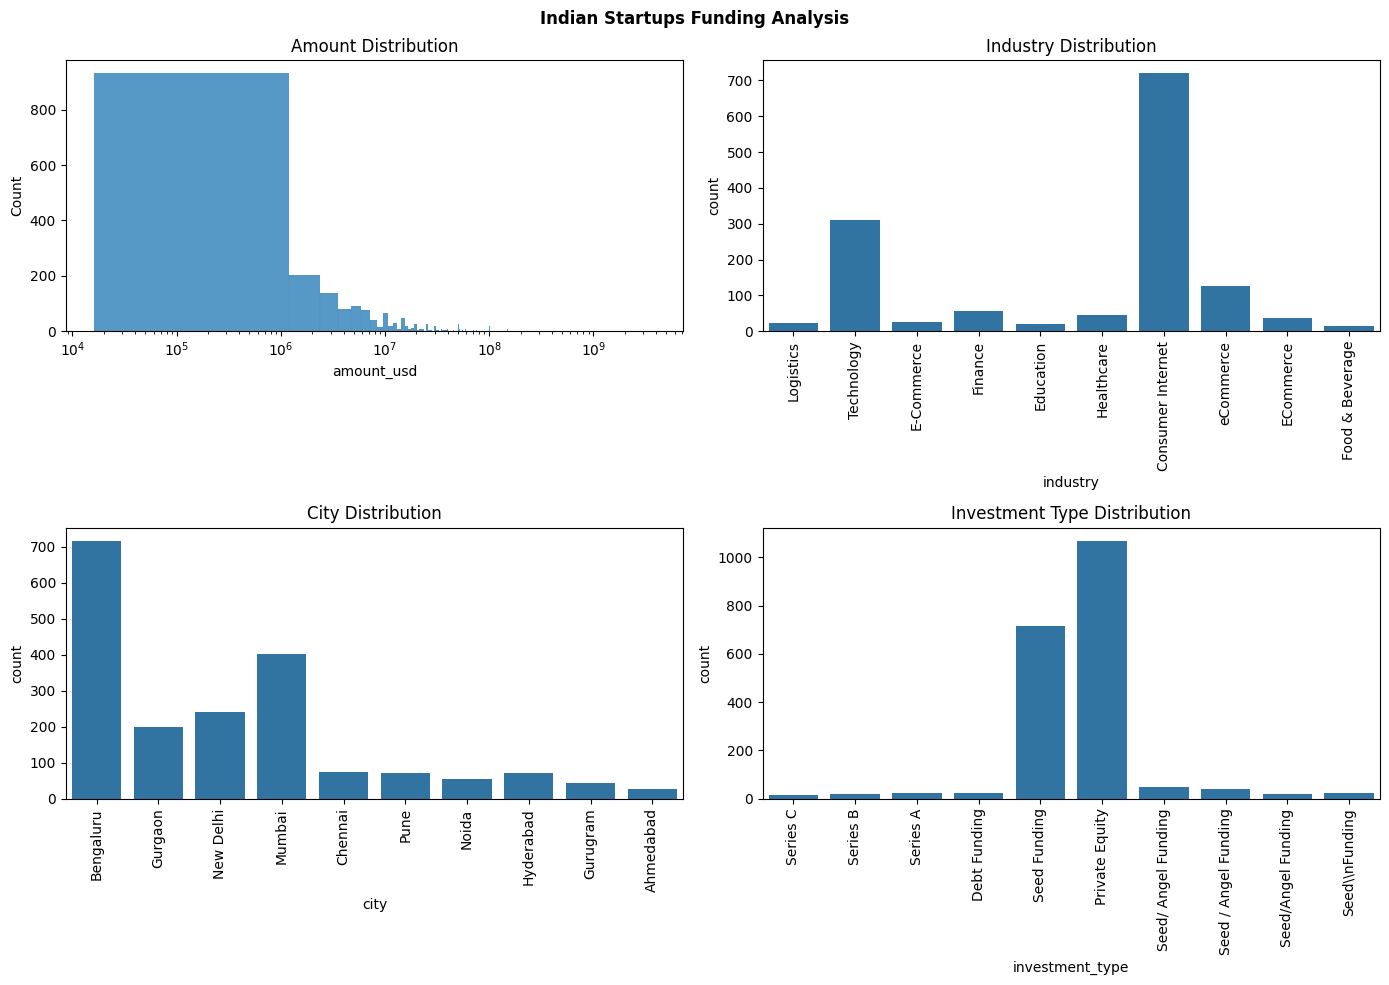

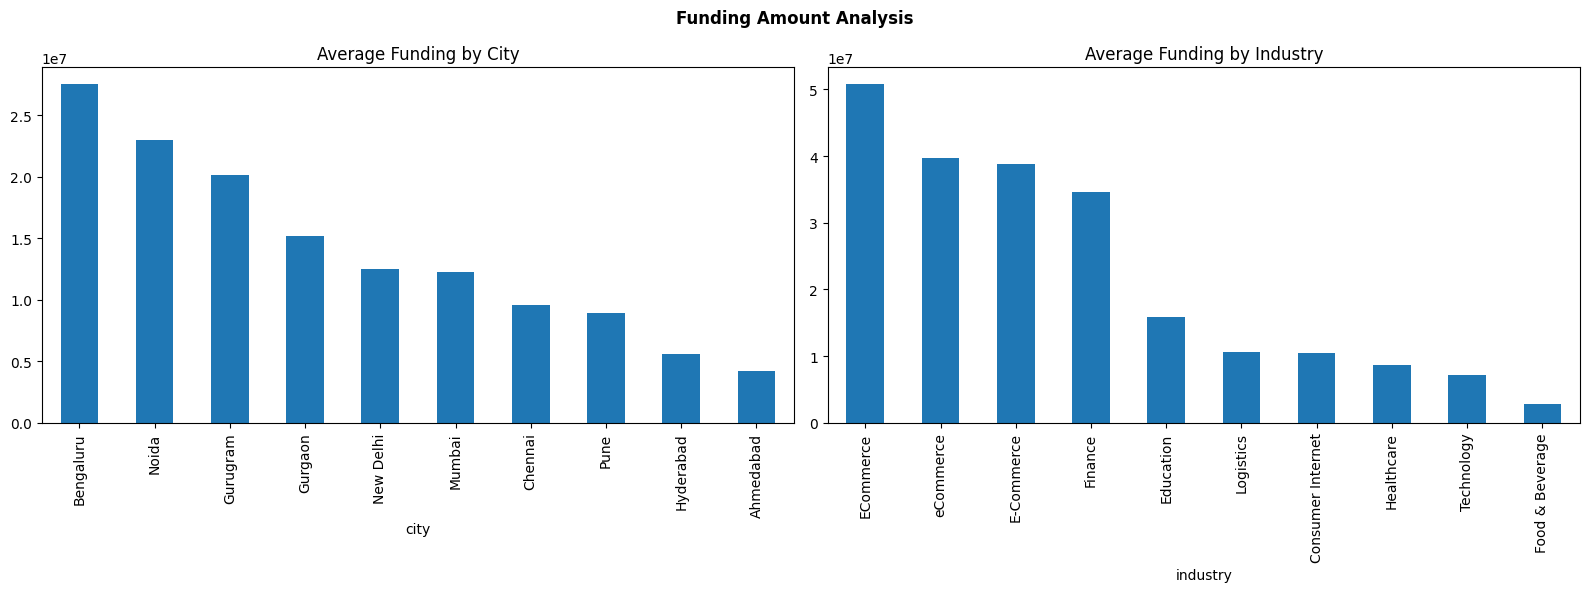

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/startup_funding.csv')
df.head()
df.shape
df.info()
df.columns = ['sr_no', 'date', 'startup_name', 'industry',
              'sub_vertical', 'city', 'investors',
              'investment_type', 'amount_usd', 'remarks']
df.columns
df.isnull().sum()
df.duplicated().sum()

#cleaning
df.drop(['remarks','sr_no','sub_vertical'], axis=1, inplace=True)
df.drop_duplicates(inplace=True)
df.shape

df['industry'].fillna(df['industry'].mode()[0], inplace=True)
df['city'].fillna(df['city'].mode()[0], inplace=True)
df['investment_type'].fillna(df['investment_type'].mode()[0], inplace=True)

df['investors'] = df['investors'].fillna('Unknown')
df.dropna(subset=['amount_usd'],inplace=True)
df.isnull().sum()

df['amount_usd'] = df['amount_usd'].str.replace(',', '')
df['amount_usd'] = df['amount_usd'].replace('undisclosed', pd.NaT)
df['amount_usd'] = pd.to_numeric(df['amount_usd'], errors='coerce')
df.dropna(subset=['amount_usd'], inplace=True)
df['city'] = df['city'].str.replace('Bangalore', 'Bengaluru')

df.shape
df['amount_usd'].dtype

df.describe()
df.describe(include='object')

#univariate Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Indian Startups Funding Analysis", fontweight='bold')

# Plot 1 — Amount Distribution
sns.histplot(data=df, x='amount_usd', ax=axes[0,0])
axes[0,0].set_xscale('log')
axes[0,0].set_title('Amount Distribution')

# Plot 2 — Industry Distribution
top10_industry = df['industry'].value_counts().head(10).index
sns.countplot(data=df[df['industry'].isin(top10_industry)], x='industry', ax=axes[0,1])
axes[0,1].set_title('Industry Distribution')
axes[0,1].tick_params(axis='x', rotation=90)

# Plot 3 — City Distribution
top10_city = df['city'].value_counts().head(10).index
sns.countplot(data=df[df['city'].isin(top10_city)], x='city', ax=axes[1,0])
axes[1,0].set_title('City Distribution')
axes[1,0].tick_params(axis='x', rotation=90)

# Plot 4 — Investment Type Distribution
top10_inv = df['investment_type'].value_counts().head(10).index
sns.countplot(data=df[df['investment_type'].isin(top10_inv)], x='investment_type', ax=axes[1,1])
axes[1,1].set_title('Investment Type Distribution')
axes[1,1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

axes[0,0].set_title('Amount Distribution')
axes[0,0].set_xscale('log')
axes[0,1].set_title('Industry Distribution')
axes[0,1].tick_params(axis='x', rotation=90)
axes[1,0].set_title('City Distribution')
axes[1,1].set_title('Investment Type Distribution')
axes[1,1].tick_params(axis='x', rotation=90)

plt.show()

#Bivariate Analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Funding Amount Analysis", fontweight='bold')

# Plot 1 — Average funding by city
top10_city = df['city'].value_counts().head(10).index
city_avg = df[df['city'].isin(top10_city)].groupby('city')['amount_usd'].mean().sort_values(ascending=False)
city_avg.plot(kind='bar', ax=axes[0])
axes[0].set_title('Average Funding by City')
axes[0].tick_params(axis='x', rotation=90)

# Plot 2 — Average funding by industry
top10_industry = df['industry'].value_counts().head(10).index
industry_avg = df[df['industry'].isin(top10_industry)].groupby('industry')['amount_usd'].mean().sort_values(ascending=False)
industry_avg.plot(kind='bar', ax=axes[1])
axes[1].set_title('Average Funding by Industry')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

